# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


En el titanic a la hora de evacuar se priorizó a las mujeres y a los niños por lo que esto puede estar relacionado a la supervivencia. También, las personas de mayor clase social, o con pasajes  mas caros, tenian un acceso mas cercano al lugar de evacuación. 

## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos. 
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas. 
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [7]:
titanic = pd.read_csv("titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **cuáles variables son numéricas y cuáles son numéricas?**



Las variables categóricas son:  "survived", "Pclass", "name", "sex", "ticket", "cabin" y "Embarked". 


Las variavles numéricas son: "PassengerId", "age", "SibSp", "Parch" y "fare".


# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

In [14]:
n_pasajeros = titanic.shape[0]
print( 'Hay {} pasajeros' .format(n_pasajeros))


Hay 891 pasajeros


### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


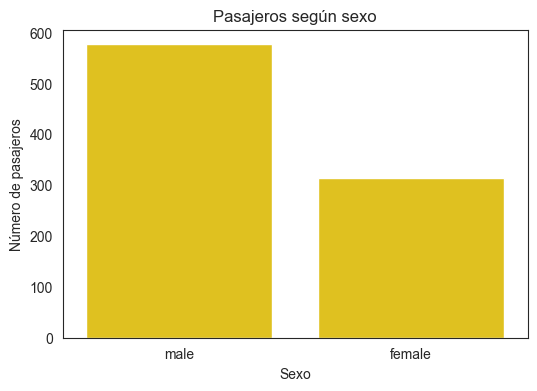

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="gold")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
- La muestra está balanceada entre las tres clases?


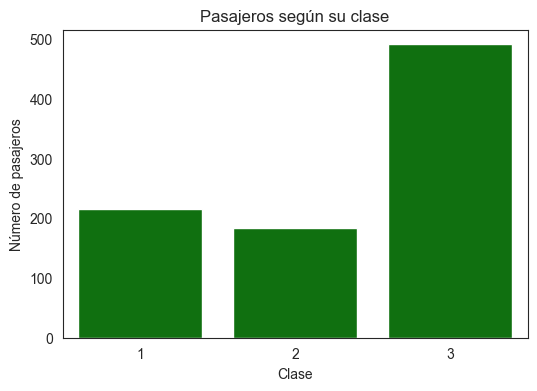

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=titanic, x="Pclass", color="green")
plt.xlabel("Clase")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según su clase")

plt.show()

**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?
- ¿La distribución parece simétrica?
- ¿El número de bins cambia su interpretación?


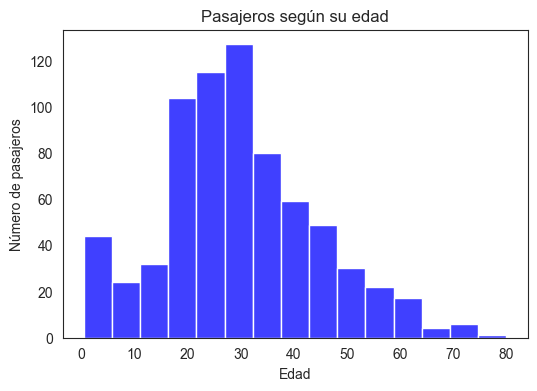

In [22]:
# Escriba aquí su código
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="Age", color="blue", bins = 15)
plt.xlabel("Edad")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según su edad")

plt.show()


**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?
- ¿Existen tarifas muy superiores al resto?
- ¿Qué podría significar esto?


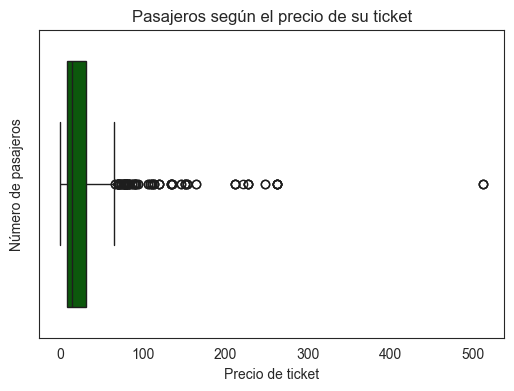

In [91]:
# Escriba aquí su código
plt.figure(figsize=(6,4))
sns.boxplot(data=titanic, x="Fare", color="darkgreen")
plt.xlabel("Precio de ticket")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según el precio de su ticket")

plt.show()


Se puede ver que hay unos ticket que tienen una tarifa de mas de 1000 incluso llegando a 500.

Al hacer zoom ente 50 y 550 se puede ver mejor:


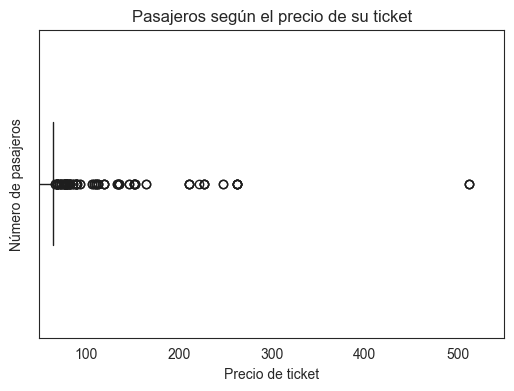

In [93]:
# Escriba aquí su código
plt.figure(figsize=(6,4))
sns.boxplot(data=titanic, x="Fare", color="darkgreen")
plt.xlabel("Precio de ticket")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según el precio de su ticket")
plt.xlim(50,550)

plt.show()


Se puede ver que hay muy pocos pasajeros en este rango, lo que nos da pistas de que estos son otliers ya que son exesivamente mas grande sque el resto de tarifas. 
Ademas estos estan fuera del IQR y del SIQR por lo que son outliers

Si graficaramos sin estos outliers se tendria:

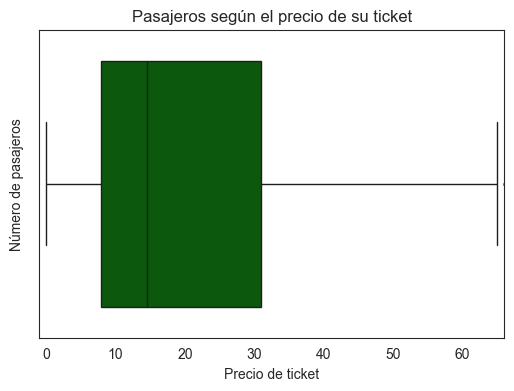

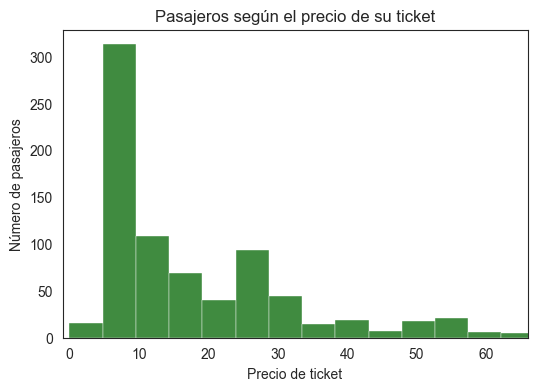

In [100]:
# Escriba aquí su código
plt.figure(figsize=(6,4))
sns.boxplot(data=titanic, x="Fare", color="darkgreen")
plt.xlabel("Precio de ticket")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según el precio de su ticket")
plt.xlim(-1,66)

plt.show()


plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="Fare", color="darkgreen")
plt.xlabel("Precio de ticket")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según el precio de su ticket")
plt.xlim(-1,66)

plt.show()

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [41]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [47]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Podemos ver que en la columna de edad hay 714 datos no nulos, lo que nos indica que 177 si lo son. Por lo que hay datos faltantes sobre la edad.
Además podemos ver algo similar con la columna de cabina donde solo filas 204 son no nulas. Hay 687 datos nulos.
Finalmente tambien hay 2 filas donde falta un dato no nulo para la columna de embarcamiento.

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


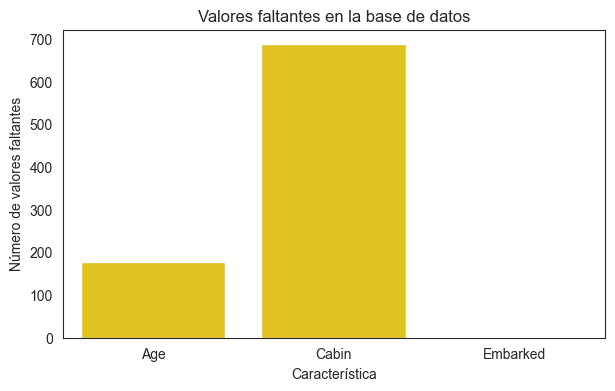

In [48]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?
- Es la media una buena representación de una edad típica?


In [56]:
# Escriba aquí su código
Edad_corregida = titanic["Age"].dropna() 
mediana_age = np.median(Edad_corregida)
print('La mediana de la edad es {}' .format(mediana_age))
media_age = np.mean(Edad_corregida)
print('La media de la edad es {}' .format(media_age))


La mediana de la edad es 28.0
La media de la edad es 29.69911764705882


Son similares estos valores, por lo que ambos pueden ser una buena representacion de la edad típica. Hay que tomar en cuenta que el promedio se ve mas afectado por outliers que la mediana, por lo que nos conviene usar esta ultima por sobre el promedio.

**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?
- Qué problema podría producir esa decisión en la distribución de edades?
- Qué otra estrategia consideraría?


Para poder saber si es prudente remplazar los datos por la media, es necesario un analisis previo de la variable. Ya que no sabemos si es que la distribucion de la edad es igual dependiendo de alguna otra variable. Por ejemplo veremos como se ve afectada la edad segun la clase del pasajero.

Se separan los dartos segun clase:

In [90]:
clase1 = titanic[titanic["Pclass"] == 1]["Age"].tolist()
clase2 = titanic[titanic["Pclass"] == 2]["Age"].tolist()
clase3 = titanic[titanic["Pclass"] == 3]["Age"].tolist()

Ahora haceos un histograma de edad para cada clase por separado:

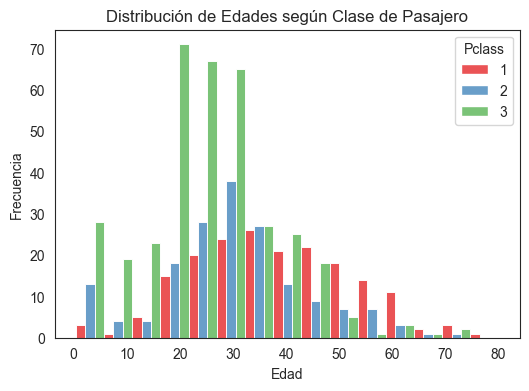

In [150]:
plt.figure(figsize=(6,4))
sns.histplot(data=titanic, x="Age", hue="Pclass", bins=15, multiple="dodge", palette="Set1")

plt.title("Distribución de Edades según Clase de Pasajero")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

Se ve que para los pasajeros de clase 3 tienden a ser mas jovenes que los de clase 2 o 1, donde estos ultimos son los mayores en promedio.

Si se quiere añadir los valores faltantes de edades, es necesario considerar la clase. Se podria añadir la edad mediana para cada clase por separado. 

**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?
- Eliminaría la característica?
- Podría el hecho de conocer o no la cabina contener información por sí mismo?

No hay una única respuesta correcta: justifique su decisión.


Conocer la cabina no es relevante en este caso ya que no hay info sobre la diferencia entre cada cabina. Si se quiere usar la cabina para saber que tan caro era el pasaje o la clase del pasajero se puede usar, Pclass y fare. Por lo que prongo eliminar la caracteristica o no considerarla.

**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?
- Por qué el tratamiento puede ser distinto al de `Cabin`?


Para la cabina solo faltan 2 datos, y tomando en cuenta que el total es de 819, estos no afectan en nada. por lo que se pueden o ignorar o poner una cabina aleatoria.

# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


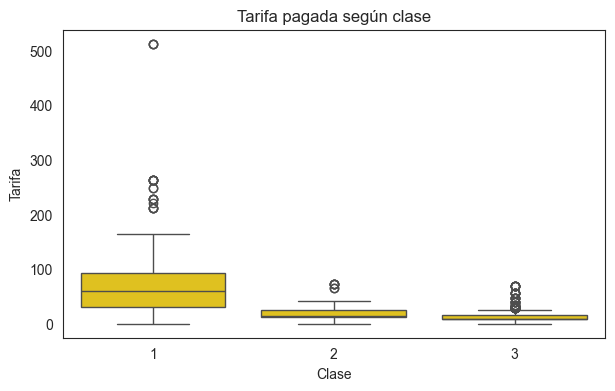

In [115]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?
- Hay dispersión dentro de cada clase?
- Existen valores extremos?
- Diría que `Fare` y `Pclass` contienen exactamente la misma información?


Se ve una relacion entre la clase y la tarifa. Las clases 1 tienen tarifas mas caras.
Se ve una disperción dentro de cada clase. Se puede ver que dentro de la clase 3 hay algunas tarifas similares a las tarifas de la clase 3. Esto se debe a que no necesariamente al ser clase 3 los pasajeros deben pagar tarigas mas baratas, existe la posibilidad de que algunos hayan pagado tarifas mas caras. 

Dentro de la clase 1 existen ciertos valores extremos los cuales podrian ser outliers. Una tarifa llega incluso hasta 500, aunque al ser una no deberia afectar mucho la estadistica.

Las categorias Fare y Pclass no contienen la misma informacion. Pclass contiene la clase, la cual puede dar una idea general de la tarifa que suele pagar la gente de esa clase. Mientras que Fare da informacion mas precisa sobre cada pasajero por separado.

### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?
- Qué diferencias observa?


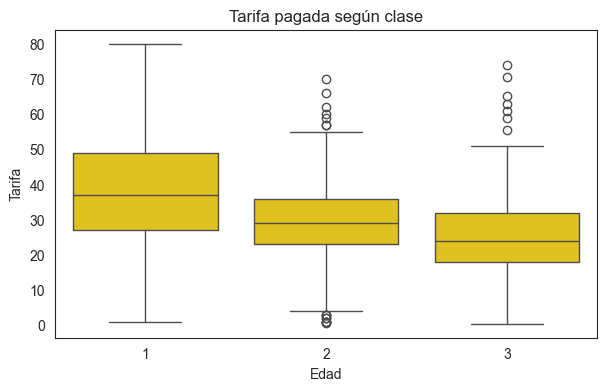

In [116]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Age", color='gold')

plt.xlabel("Edad")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()

Se ve una tendencia a mayores edades en la clase 1 mientras que en la clase 3 hay gente mas jovenes. Se ven ciertos valores extremos, sobre todo de gente mayor en clase 3.

**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [ ]:
# Complete el código
titanic["Familia"] =  titanic["SibSp"] + titanic["Parch"] + 1
titanic["Familia"]

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: Familia, Length: 891, dtype: int64

**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?
- Hay grupos familiares muy grandes?
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?


[537, 354]


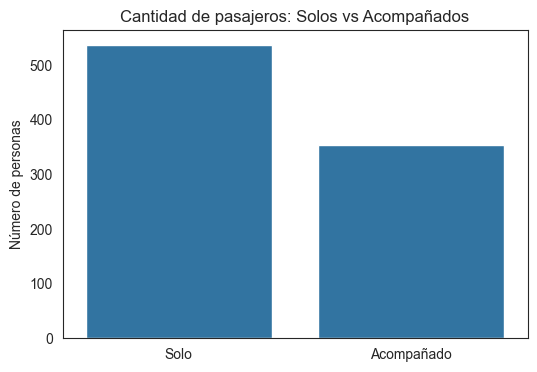

In [187]:
acompanado = titanic[titanic["Familia"] > 1]
solo = titanic[titanic["Familia"] == 1]

cantidades = [len(solo), len(acompanado)]
categorias = ["Solo", "Acompañado"]

print(cantidades)

plt.figure(figsize=(6, 4))

sns.barplot(x=categorias, y=cantidades)

plt.title("Cantidad de pasajeros: Solos vs Acompañados")
plt.ylabel("Número de personas")

plt.show()


Hay mas pasajeros que viaja solos que acompañados

<Axes: xlabel='Familia', ylabel='Count'>

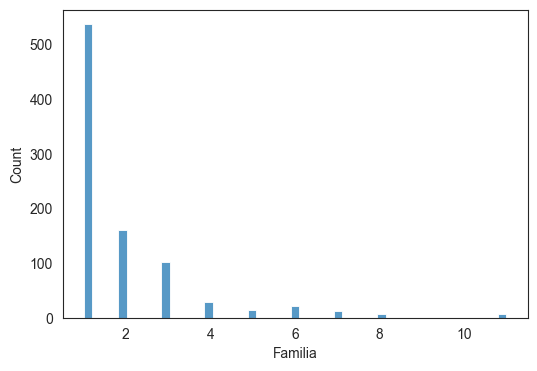

In [136]:
plt.figure(figsize=(6,4))
sns.histplot(titanic["Familia"])

Se puede ver que hay unas familias con mas de 6 integrantes lo cual es un grupo familiar grande. 

Si se analiza SibSp y Parch por separado si cambia la interpretacion. Ya que es posible qyue alguien viaje con sus padres y sin hermanos ni conyugue. Pero al anlizar el SibPs uno podria pensar que viaja solo, lo cual es incorrecto. 

# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


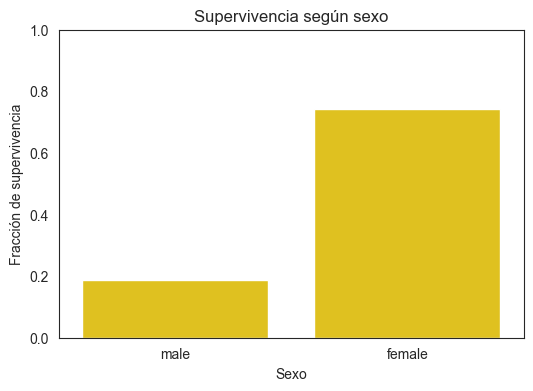

In [137]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?
- Podemos concluir a partir de este gráfico por qué existe la diferencia?


Hay una fraccion mucho mas grande de supervivencia en mujeres que en hombres. Aproximadamente el 80% de los pasajeros que sobreviven son mujeres.
Existe una diferencia entre los supervivientes debiod al sexo, pero no se puede concluir solo con eos. Es posible que hayan otros factores que afectan.

### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?
- Existe una tendencia?


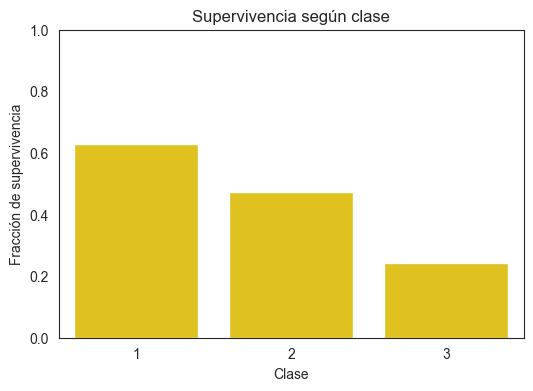

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(data = titanic, x = "Pclass", y = "Survived", errorbar=None, color='gold')
plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase")
plt.ylim(0,1)

plt.show()

Hay una mayor rupervivencia para la clase 1 que para la clase 3. Esto tambien puede implicar una relación, pero no se puede asumir que esta es la relación principal. 

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?
- Hay algún grupo de edad que llame particularmente su atención?


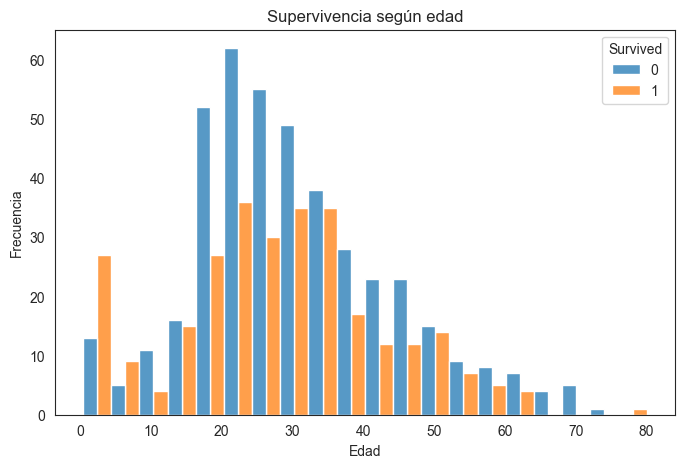

In [153]:
plt.figure(figsize=(8, 5))

sns.histplot(data=titanic, x="Age", hue="Survived", multiple = "dodge")

plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Supervivencia según edad")

plt.show()

Se puede ver que en edades menores a 10, hay mayor indice de supervivencia, mientras que en una edad cercana a 20, hay mayor indice de muerte.


**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?
- La relación parece simple?
- Qué ocurre con los grupos familiares grandes?


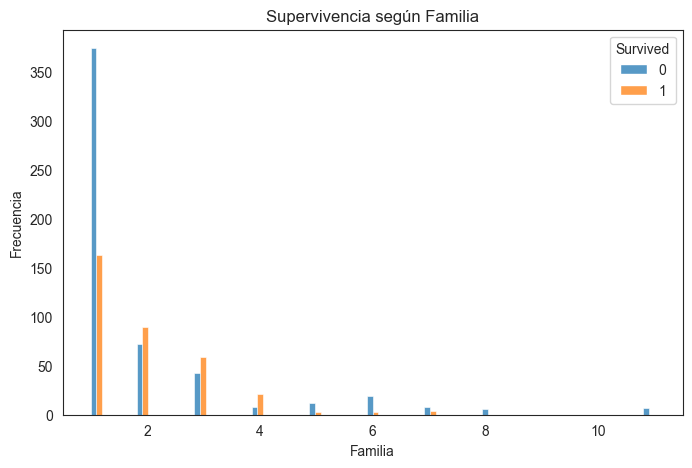

In [157]:
plt.figure(figsize=(8, 5))

sns.histplot(data=titanic, x="Familia", hue="Survived", multiple = "dodge")

plt.xlabel("Familia")
plt.ylabel("Frecuencia")
plt.title("Supervivencia según Familia")

plt.show()

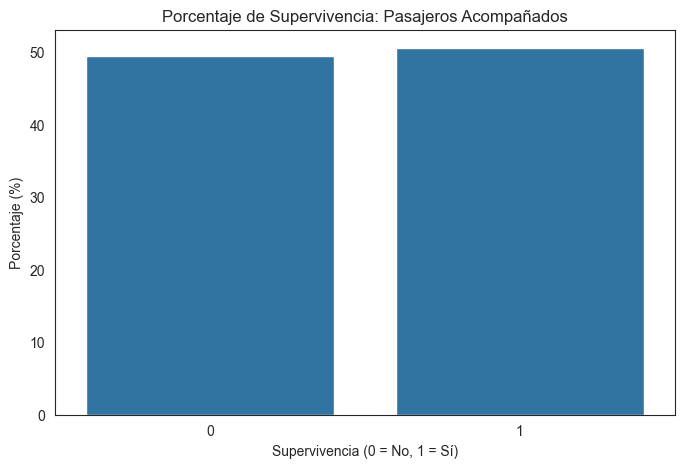

In [167]:
porcentajes = acompanado["Survived"].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))

sns.barplot(x=porcentajes.index, y=porcentajes.values)

plt.xlabel("Supervivencia (0 = No, 1 = Sí)")
plt.ylabel("Porcentaje (%)")
plt.title("Porcentaje de Supervivencia: Pasajeros Acompañados")

plt.show()

Se puede ver que la gente que viaja sola tiene menor indice de supervivencia. Mientras que para la gente acompañada, en generañ se puede ver que esta bastante parejo. La gente con familias mas pequeñas tuvo mas indice de supervivencia mientras que la gente con familias mas grandes tenian indice menor.

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


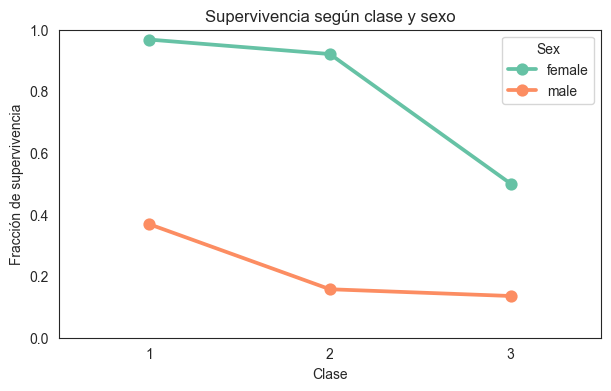

In [168]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?
- Qué información se perdía cuando mirábamos solamente `Pclass`?
- Qué información se perdía cuando mirábamos solamente `Sex`?
- Hay algún grupo particularmente favorecido o desfavorecido?



La relacion no es la misma. Se puede ver que dentro de las mujeres, casi el 100% de las calses 1 sobrebiben mientras que las clases 3 tienen menos indice de supervivencia. Con los hombres los clase 1 tienen mayor indice pero se mantienen en 40%. La relacion es distinca, pero el patron entre clases se mantiene.

Al mirar solo Pclass se trabaja toda la muestra por lo que no se diferencia el sexo. Esto es util ya que el indice de supervivencia, aunque este relacionado a Pclas, tambien varia segun Sex. Cuando solo se mira sex se puede ver esta diferencia, pero se pierde la diferencia entre las clases. Esto indica que no solo hay relacion entre 2 variables sino que hay mas.

El gurpo mas favorecido son las mujeres de clase 1, las cuales tienen el mayor indice de supervivencia. El grupo con menor indice son los hombres de clase 3 aunque no se diferencian mucho de los de clase 2.

### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [191]:
# Complete el código

titanic["Persona"] = np.where(titanic["Age"] < 16, "niño/a", np.where(titanic["Sex"] == "female", "mujer", "hombre"))
titanic["sexo"] = np.where(titanic["Sex"] == "female", "mujer", "hombre" )
# Revise el resultado
print(titanic["Persona"].value_counts())
print(titanic["sexo"].value_counts())


Persona
hombre    537
mujer     271
niño/a     83
Name: count, dtype: int64
sexo
hombre    577
mujer     314
Name: count, dtype: int64


**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?
- La clase sigue siendo importante dentro de cada grupo?
- Qué combinación de características parece asociarse con la mayor supervivencia?


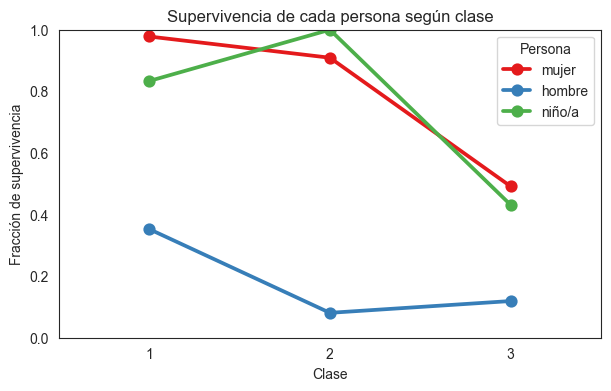

In [170]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Persona",
              palette="Set1",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia de cada persona según clase")
plt.ylim(0,1)

plt.show()


/var/folders/st/wg78bh5x6hn48fjghrl2xrh40000gn/T/ipykernel_34275/3872585783.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=ninos, x="Pclass", palette="Set2")


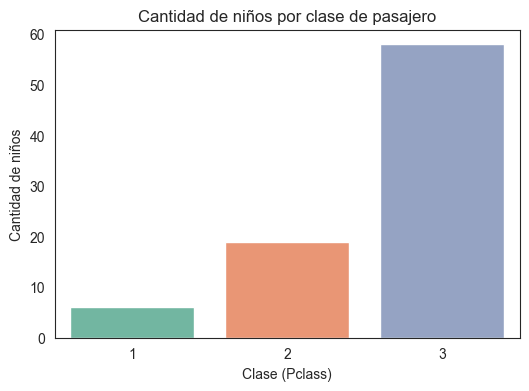

In [172]:
ninos = titanic[titanic["Persona"] == "niño/a"]

plt.figure(figsize=(6, 4))

sns.countplot(data=ninos, x="Pclass", palette="Set2")

plt.title("Cantidad de niños por clase de pasajero")
plt.xlabel("Clase (Pclass)")
plt.ylabel("Cantidad de niños")

plt.show()

Los niños tienen un mayor indice de supervivencia que los hombres. Este es bastante similar al de las mujeres aunque no sigue el mismo patron. Aqui sobreviven mas niños de clase 2 que de clase 1. Esto puede estar dado a que hay muchos mas niños de clase 2 que 1 aunque la mayoria son de clase 3. Estos ultimos tienen menos indice supervivencia siguiend0 el patron de hombres y mujeres. 

La clase sigue siendo importante en cada categoria ya que se ve un patron que se suele repetir.

La mayor supervivencia esta asociada a las mujeres de clase 1

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


¿Cómo varía la supervivencia según la cantidad total de familiares a bordo y la clase del pasajero?

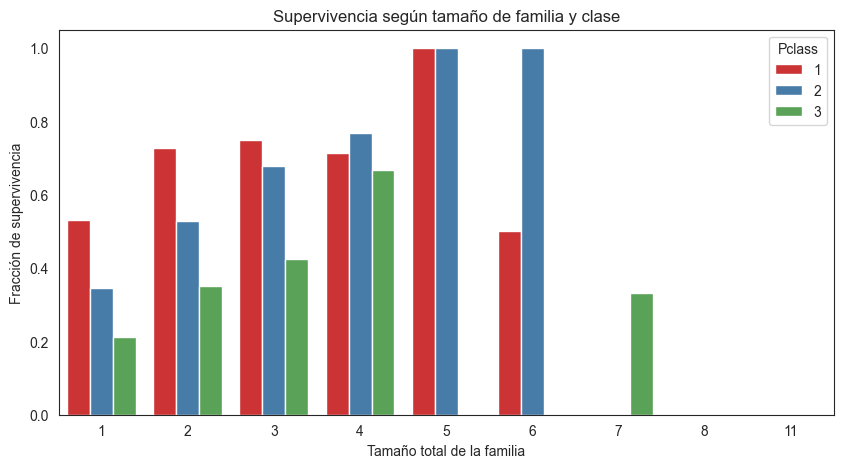

In [184]:
plt.figure(figsize=(10, 5))

sns.barplot(data=titanic, x="Familia", y="Survived", hue="Pclass", palette="Set1", errorbar= None)

plt.xlabel("Tamaño total de la familia")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según tamaño de familia y clase")

plt.show()

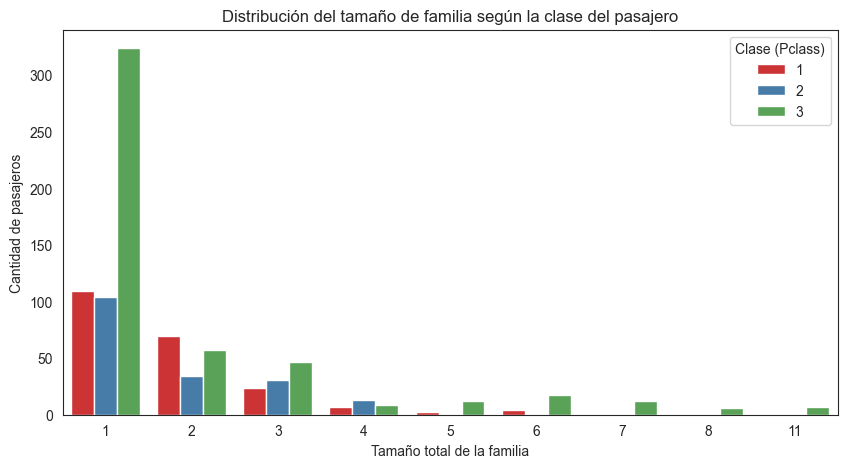

In [204]:
plt.figure(figsize=(10, 5))

sns.countplot(data=titanic, x="Familia", hue="Pclass", palette="Set1")

plt.title("Distribución del tamaño de familia según la clase del pasajero")
plt.xlabel("Tamaño total de la familia")
plt.ylabel("Cantidad de pasajeros")
plt.legend(title="Clase (Pclass)")

plt.show()

La primera clase tuvo mayor tasa de supervivencia en casi todas las agrupaciones de familia. seguida por la segunda y luego la tercerra clase. La exepcion es en el tamaño de familia 6 donde hubo un indice de supervivencia del 100%

Las familias con entre 2 y 4 integrantes mostraron la tendencia de supervivencia más consistente para las tres clases juntas, superando claramente a los pasajeros que viajaban solos.

Las familias mas grandes pertenecían casi exclusivamente a la tercera clase y registraron los peores resultados, con una supervivencia nula para los grupos de 8 y 11 personas.

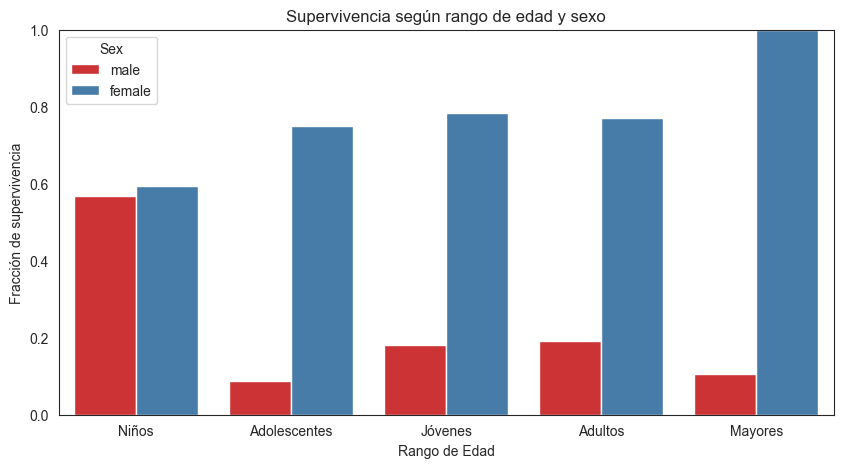

In [206]:
import pandas as pd

titanic["Rango_Edad"] = pd.cut(titanic["Age"], bins=[0, 12, 18, 35, 60, 100], labels=["Niños", "Adolescentes", "Jóvenes", "Adultos", "Mayores"])

plt.figure(figsize=(10, 5))

sns.barplot(data=titanic, x="Rango_Edad", y="Survived", hue="Sex", palette="Set1", errorbar=None)

plt.xlabel("Rango de Edad")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según rango de edad y sexo")
plt.ylim(0, 1)

plt.show()

# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

Esta es una muetras de datos grande por lo que el comportamienteo estadistico es acertado. Se vió una tendencia en la que sobrevivieron las mujeres y niños. Sin embargo, la conclusión aqui es que sobreviveron mas mujeres y niños, pero no hay informacion sohbre el proceso de evacuación. Este resultado puede ser debido a otras razones. 

Se necesitaria información adicional sobre el metodo de evacuación o sobre las medidas que se tomaron. No porque las mujeres y niños hayan sobrevivido mas significa que tenian prioridad.

Existe la posibilidad de que las mujeres y niños se encontraban mas cerca de la cubierta para evacuar debido a que habia mayor tendencia por parte de estos a ser de clase 1, ya que vimos que la clase tiene influencia sobre la supervivencia. 



## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

Describa brevemente la muestra considerando, al menos:

- sexo
- clase
- edad
- tamaño de familia.


### 2. Qué características estaban asociadas con la supervivencia?

Considere:

- sexo
- clase
- edad
- viajar solo o acompañado.



### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Use como ejemplo al menos uno de los análisis multivariados realizados.


### 4. Encontró características que contienen información relacionada?

Explique al menos un caso.


### 5. Qué resultado le pareció más inesperado?

Proponga una posible explicación, dejando claro qué parte corresponde a una observación y qué parte corresponde a una hipótesis.


1. En el titanic habia un total de 891 pasajeros. 537 de estos viajaban solos mientras que 354 viajaban acompañados. Habian 577 hombre y 314 mujeres. De la muestra total 83 pasajeros tenian menos de 16 años. Si dejamos de lado los pasajeros niños y niñas, en total eran 537 hombres 271 mujeres.

In [202]:
supervivientes = titanic[titanic["Survived"] == 1]
cantidades = supervivientes["Persona"].value_counts()
totales = titanic["Persona"].value_counts()

porcentajes = (cantidades / totales * 100).round(2)

print("cantidad supervivientes:")
print(cantidades)
print("porcentaje supervivencia:")
print(porcentajes)
print("----------------")
supervivientes = titanic[titanic["Survived"] == 1]
cantidades_clase = supervivientes["Pclass"].value_counts()
totales_clase = titanic["Pclass"].value_counts()

porcentajes_clase = (cantidades_clase / totales_clase * 100).round(2)

print("Cantidad de supervivientes:")
print(cantidades_clase)
print("Porcentaje de supervivencia:")
print(porcentajes_clase)
print("----------------")


titanic.loc[titanic["Familia"] == 1, "Estado"] = "Solo"
titanic.loc[titanic["Familia"] > 1, "Estado"] = "Acompañado"

supervivientes = titanic[titanic["Survived"] == 1]
cantidades_estado = supervivientes["Estado"].value_counts()
totales_estado = titanic["Estado"].value_counts()

porcentajes_estado = (cantidades_estado / totales_estado * 100).round(2)

print("Cantidad de supervivientes:")
print(cantidades_estado)
print("Porcentaje de supervivencia:")
print(porcentajes_estado)

cantidad supervivientes:
Persona
mujer     205
hombre     88
niño/a     49
Name: count, dtype: int64
porcentaje supervivencia:
Persona
hombre    16.39
mujer     75.65
niño/a    59.04
Name: count, dtype: float64
----------------
Cantidad de supervivientes:
Pclass
1    136
3    119
2     87
Name: count, dtype: int64
Porcentaje de supervivencia:
Pclass
1    62.96
2    47.28
3    24.24
Name: count, dtype: float64
----------------
Cantidad de supervivientes:
Estado
Acompañado    179
Solo          163
Name: count, dtype: int64
Porcentaje de supervivencia:
Estado
Acompañado    50.56
Solo          30.35
Name: count, dtype: float64


2. En total sobreviveron 205 mujeres (75,65%), 88 hombres (16,39%) y 49 niños (59,04%). Por otra parte sobrevivieron 139 pasajeros de clase 1 (62.96%), 119 de clase 2 (47.28%) y 87 pasajeros de clase 3 (24.24%). Luego se vió que la gente que viajaba sola sobreviveron 163 (30.35%) y de los que viajaban acompañados sobreviveron 179 (50.56%). Por ultimo, se vio que habia una tendencia de supervivencia hacia edades mas pequeñas. La gente mas joven sobrevivia mas que la mas grande.

3. El grafico de supervivencia segun tamaño de famlia y clase muestra tres caracteristicas. A primera vista parece que tener familia mas grande es una condena ya que la mayoria murió, pero se puede ver que las mayoria de los pasajeros de familias grandes, eran de clase 3. Por lo que la tasa de superrvivencia esta mas relacionada a la clase en este caso.

4. Las columnas de "Fare" y "Pclass" dan informacion muy parecida. Los pasajeros de clase 1 tienen mas dinero, por lo que las tarifas de sus pasajes es mayor. Mientras que los pasajeros de clase 3 tenian pasajes con menor tarifa.

5. Un resultado interesante es la diferencia de supervivencia entre pasajeros que viajan solos y los que viajan acompañados. Al viaja solo no hay preocupaciones ademas de uno mismo, y se tiene mayor movilidad. Pero los pasajeros que viajaban solos presentaron menor indice de supervivencia que los que viajan compañados. 

# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

*(Complete con un párrafo breve basado en su análisis.)*


El pasajero tipico que sobrevivio es una mujer o un niño (de 16 años o menos) alojado en primera clase. Se vio segun los datos que el género y la edad fueron muy importantes. Las mujeres presentaron una tasa de supervivencia del 75.65% y los niños del 59.04%, superando por mnucho al 16.39% de los hombres adultos. Además, la clase jugó un rol clave, ya que ser de la primera clase permitio un 62.96% de probabilidad de supervivencia, la cual baja a solo un 24.24% en la tercera clase. Finalmente, el tamaño de la familia también influyó. El pasajero con mayor indice de supervivencia no viajaba solo. Viaja acomcompañado le permitio al pasajero subir su indice de supervivencia a 50.56%, donde el tamaño optimo es de entre 2 y 4 personas.